# Anomaly Detection on AI-Agent Access Behavior

**Author:** Jonathan Ekwere  
**Background:** Security engineer (vulnerability management @ Kinaxis; technical support on BeyondTrust's Pathfinder identity-security stack, which now governs AI-agent identities). This project applies ML to a problem adjacent to my day work: spotting when an AI agent's access behavior looks anomalous.

## The problem

AI agents increasingly act with real privileges — reading resources, calling APIs, escalating access. Most of that behavior is routine. The security question: **which sequences of actions look anomalous**, signalling a compromised, misconfigured, or misbehaving agent? This is the kind of question identity-security platforms (e.g. BeyondTrust Pathfinder) are now built to answer.

## Approach

Model *normal* agent behavior over short action sequences, then flag sequences that deviate. Baseline model: Isolation Forest (unsupervised, interpretable). Unit of analysis: rolling windows of actions, not single actions — because the meaningful anomalies are *patterns* (escalation chains, unusual ordering), not individual events.

## ⚠️ HONEST STATUS — this is a multi-day build in progress

**Day 1 (this notebook):** synthetic data generator + feature engineering + Isolation Forest baseline + evaluation scaffold.

**The hard part, not yet solved (Days 2–3):** the synthetic data is currently *too easy* — the injected anomalies are fairly obvious, so the model's good scores here are NOT evidence it would work on real logs. The real work is making the synthetic 'attacks' subtle enough to be a genuine test, then adding a second model (autoencoder) and comparing. Sections marked **`# TODO (harder)`** are where that work lives. I'd rather ship this honestly mid-build than overstate it.

Everything runs with standard libraries, no external data.

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print('Ready.')

Ready.


## 1. Synthetic agent-action logs

We define a small vocabulary of agent actions and generate sessions. *Normal* sessions follow common patterns; *anomalous* sessions inject suspicious behavior (e.g. privilege escalation followed by bulk data access).

**Honest note:** the realism of this generator is the whole ballgame. Right now it's a first pass.

In [7]:
ACTIONS = [
    'read_doc', 'list_resources', 'call_api', 'write_doc',
    'request_access', 'escalate_privilege', 'bulk_export', 'delete_resource'
]
A2I = {a: i for i, a in enumerate(ACTIONS)}

# Normal agents mostly read / list / call APIs, occasionally write.
NORMAL_WEIGHTS = np.array([0.30, 0.25, 0.25, 0.12, 0.05, 0.01, 0.01, 0.01])

def make_normal_session(length):
    return list(rng.choice(ACTIONS, size=length, p=NORMAL_WEIGHTS))

def make_anomalous_session(length):
    # TODO (harder): this anomaly is currently too 'loud' — a clear escalate->bulk_export->delete
    # chain. Real malicious agents blend in. Days 2-3: make anomalies subtler (e.g. only
    # slightly elevated escalation rate, anomalies spread across a session) so the model
    # is actually challenged. If detection stays near-perfect after that, the test is too easy.
    s = make_normal_session(length)
    inject_at = rng.integers(0, max(1, length - 3))
    s[inject_at:inject_at+3] = ['escalate_privilege', 'bulk_export', 'delete_resource']
    return s

N_NORMAL, N_ANOM = 2000, 100   # imbalanced, like reality
sessions, labels = [], []
for _ in range(N_NORMAL):
    L = int(rng.integers(8, 20)); sessions.append(make_normal_session(L)); labels.append(0)
for _ in range(N_ANOM):
    L = int(rng.integers(8, 20)); sessions.append(make_anomalous_session(L)); labels.append(1)
labels = np.array(labels)
print(f'{len(sessions)} sessions ({labels.sum()} anomalous, {100*labels.mean():.1f}%)')
print('Example normal: ', sessions[0][:8])
print('Example anomalous:', sessions[-1][:8])

2100 sessions (100 anomalous, 4.8%)
Example normal:  [np.str_('list_resources'), np.str_('write_doc'), np.str_('call_api'), np.str_('read_doc'), np.str_('escalate_privilege'), np.str_('call_api'), np.str_('call_api'), np.str_('read_doc')]
Example anomalous: [np.str_('list_resources'), np.str_('list_resources'), np.str_('read_doc'), np.str_('read_doc'), np.str_('call_api'), np.str_('read_doc'), 'escalate_privilege', 'bulk_export']


## 2. Feature engineering over sequences

Turn each variable-length session into a fixed feature vector: action frequencies + a couple of simple sequence signals.

**TODO (harder):** richer sequence features (n-gram transition probabilities, entropy, rare-transition counts) are where sequence modeling earns its keep. The current features are a starting set.

In [8]:
def featurize(session):
    counts = np.zeros(len(ACTIONS))
    for a in session:
        counts[A2I[a]] += 1
    freq = counts / len(session)
    # simple sequence signals
    escalations = sum(1 for a in session if a == 'escalate_privilege')
    # count 'sensitive transitions': escalate immediately followed by export/delete
    sens_trans = sum(
        1 for i in range(len(session)-1)
        if session[i] == 'escalate_privilege' and session[i+1] in ('bulk_export', 'delete_resource')
    )
    return np.concatenate([freq, [escalations, sens_trans, len(session)]])

X = np.vstack([featurize(s) for s in sessions])
feat_names = ACTIONS + ['n_escalations', 'sensitive_transitions', 'session_len']
print('Feature matrix:', X.shape)

Feature matrix: (2100, 11)


## 3. Isolation Forest baseline

Unsupervised: we train *without* labels (anomaly detection learns 'normal' and flags outliers), then use the held-out labels only to *evaluate*. `contamination` is set to the true anomaly rate — in production you wouldn't know this, which is itself a real limitation to discuss.

In [9]:
Xs = StandardScaler().fit_transform(X)
iso = IsolationForest(contamination=N_ANOM/(N_NORMAL+N_ANOM), random_state=42, n_estimators=300)
iso.fit(Xs)
scores = -iso.score_samples(Xs)        # higher = more anomalous
preds = (iso.predict(Xs) == -1).astype(int)

print(f'ROC-AUC: {roc_auc_score(labels, scores):.4f}')
print(classification_report(labels, preds, digits=3))
print('Confusion matrix:\n', confusion_matrix(labels, preds))

ROC-AUC: 0.9927
              precision    recall  f1-score   support

           0      0.987     0.987     0.987      2000
           1      0.740     0.740     0.740       100

    accuracy                          0.975      2100
   macro avg      0.863     0.863     0.863      2100
weighted avg      0.975     0.975     0.975      2100

Confusion matrix:
 [[1974   26]
 [  26   74]]


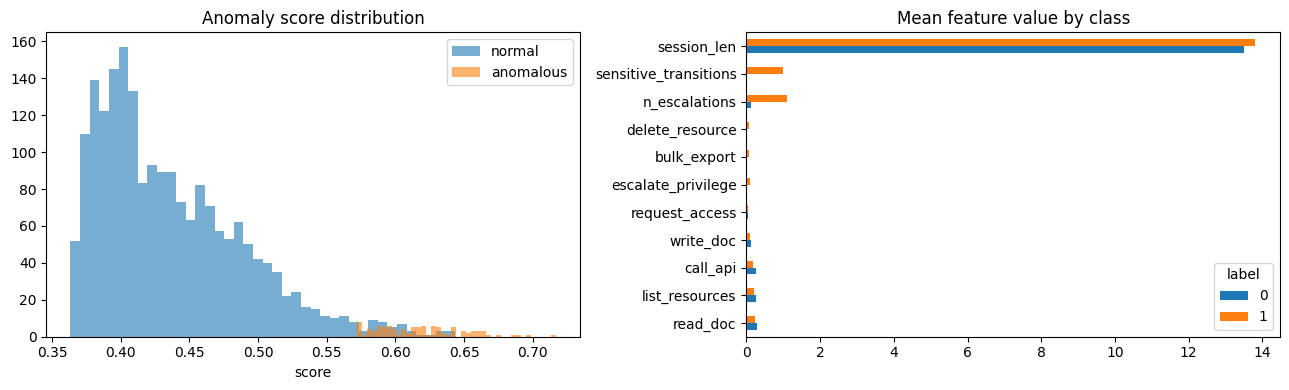

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(scores[labels==0], bins=40, alpha=0.6, label='normal')
ax[0].hist(scores[labels==1], bins=40, alpha=0.6, label='anomalous')
ax[0].set_title('Anomaly score distribution'); ax[0].set_xlabel('score'); ax[0].legend()

# crude feature signal: mean by class
means = pd.DataFrame(X, columns=feat_names).assign(label=labels).groupby('label').mean().T
means.plot.barh(ax=ax[1]); ax[1].set_title('Mean feature value by class')
plt.tight_layout(); plt.show()

## 4. Honest read & the real roadmap

**What to expect from Day 1:** detection here will likely look *very* good — and that is the warning sign, not the win. The injected anomalies are currently obvious (a loud escalate→export→delete chain), so the model catches them easily. That tells us almost nothing about real-world performance.

**Days 2–3 (the actual work):**
- Make anomalies subtle (see `# TODO (harder)` in section 1) until detection becomes genuinely hard — that's when the project means something.
- Add richer sequence features (transition probabilities, entropy).
- Add an autoencoder and compare it to Isolation Forest.
- Drop the `contamination`-knows-the-answer shortcut; test threshold selection without peeking at labels.

**Why this connects to my work:** identity-security platforms like BeyondTrust Pathfinder now map and monitor AI-agent privileges and access paths. This is a toy model of that detection problem — built to learn the ML side of something I already understand operationally.

In [11]:
# --- Harder synthetic data: subtle anomalies ---
# Normal agents very occasionally escalate legitimately, so escalation isn't a free giveaway.
NORMAL_WEIGHTS_V2 = np.array([0.28, 0.24, 0.24, 0.12, 0.06, 0.03, 0.02, 0.01])
#                            read  list  api   write req  escal export delete

def make_normal_v2(length):
    return list(rng.choice(ACTIONS, size=length, p=NORMAL_WEIGHTS_V2))

def make_anomalous_v2(length):
    # Subtle: start from a normal session, then NUDGE it toward risk rather than stamping a chain.
    # - slightly raise escalation/export likelihood
    # - place at most one or two sensitive actions, scattered (not adjacent)
    s = make_normal_v2(length)
    n_inject = rng.integers(1, 3)  # 1 or 2 subtle insertions
    for _ in range(n_inject):
        pos = rng.integers(0, length)
        s[pos] = rng.choice(['escalate_privilege', 'bulk_export', 'request_access'],
                            p=[0.4, 0.35, 0.25])
    return s

sessions2, labels2 = [], []
for _ in range(N_NORMAL):
    L = int(rng.integers(8, 20)); sessions2.append(make_normal_v2(L)); labels2.append(0)
for _ in range(N_ANOM):
    L = int(rng.integers(8, 20)); sessions2.append(make_anomalous_v2(L)); labels2.append(1)
labels2 = np.array(labels2)
print(f'{len(sessions2)} sessions ({labels2.sum()} anomalous)')
print('Normal example:   ', sessions2[5][:10])
print('Anomalous example:', sessions2[-1][:10])
print('\nNote: the anomalous one should NOT look obviously different at a glance — that is the goal.')

2100 sessions (100 anomalous)
Normal example:    [np.str_('escalate_privilege'), np.str_('call_api'), np.str_('escalate_privilege'), np.str_('write_doc'), np.str_('call_api'), np.str_('list_resources'), np.str_('list_resources'), np.str_('read_doc'), np.str_('list_resources'), np.str_('write_doc')]
Anomalous example: [np.str_('list_resources'), np.str_('call_api'), np.str_('read_doc'), np.str_('bulk_export'), np.str_('write_doc'), np.str_('list_resources'), np.str_('call_api'), np.str_('delete_resource'), np.str_('list_resources'), np.str_('bulk_export')]

Note: the anomalous one should NOT look obviously different at a glance — that is the goal.


In [12]:
# --- Harder features: drop the giveaway, keep only signals that also occur in normal traffic ---
def featurize_v2(session):
    counts = np.zeros(len(ACTIONS))
    for a in session:
        counts[A2I[a]] += 1
    freq = counts / len(session)
    # behavioral signals that are matters-of-degree, not presence/absence:
    escalation_rate = counts[A2I['escalate_privilege']] / len(session)
    export_rate     = counts[A2I['bulk_export']] / len(session)
    # transition entropy: how varied are the action-to-action transitions (lower can mean fixation)
    trans = [(session[i], session[i+1]) for i in range(len(session)-1)]
    if trans:
        _, c = np.unique(['%s>%s' % t for t in trans], return_counts=True)
        p = c / c.sum(); entropy = float(-(p*np.log2(p)).sum())
    else:
        entropy = 0.0
    return np.concatenate([freq, [escalation_rate, export_rate, entropy, len(session)]])

X2 = np.vstack([featurize_v2(s) for s in sessions2])
feat_names2 = ACTIONS + ['escalation_rate', 'export_rate', 'transition_entropy', 'session_len']
print('Feature matrix:', X2.shape)
print('Dropped the trivial `sensitive_transitions` giveaway from Day 1.')

Feature matrix: (2100, 12)
Dropped the trivial `sensitive_transitions` giveaway from Day 1.


In [13]:
# --- Re-run Isolation Forest on the harder problem ---
Xs2 = StandardScaler().fit_transform(X2)
iso2 = IsolationForest(contamination=N_ANOM/(N_NORMAL+N_ANOM), random_state=42, n_estimators=300)
iso2.fit(Xs2)
scores2 = -iso2.score_samples(Xs2)
preds2 = (iso2.predict(Xs2) == -1).astype(int)

print('=== Day 2 (harder) ===')
print(f'ROC-AUC: {roc_auc_score(labels2, scores2):.4f}')
print(classification_report(labels2, preds2, digits=3))
print('Confusion matrix:\n', confusion_matrix(labels2, preds2))
print('\nCompare to Day 1 AUC 0.99. A lower number here is the honest one — the model now has to')
print('detect anomalies from degree and pattern, not from a feature that only fires on attacks.')

=== Day 2 (harder) ===
ROC-AUC: 0.7512
              precision    recall  f1-score   support

           0      0.959     0.959     0.959      2000
           1      0.170     0.170     0.170       100

    accuracy                          0.921      2100
   macro avg      0.564     0.564     0.564      2100
weighted avg      0.921     0.921     0.921      2100

Confusion matrix:
 [[1917   83]
 [  83   17]]

Compare to Day 1 AUC 0.99. A lower number here is the honest one — the model now has to
detect anomalies from degree and pattern, not from a feature that only fires on attacks.


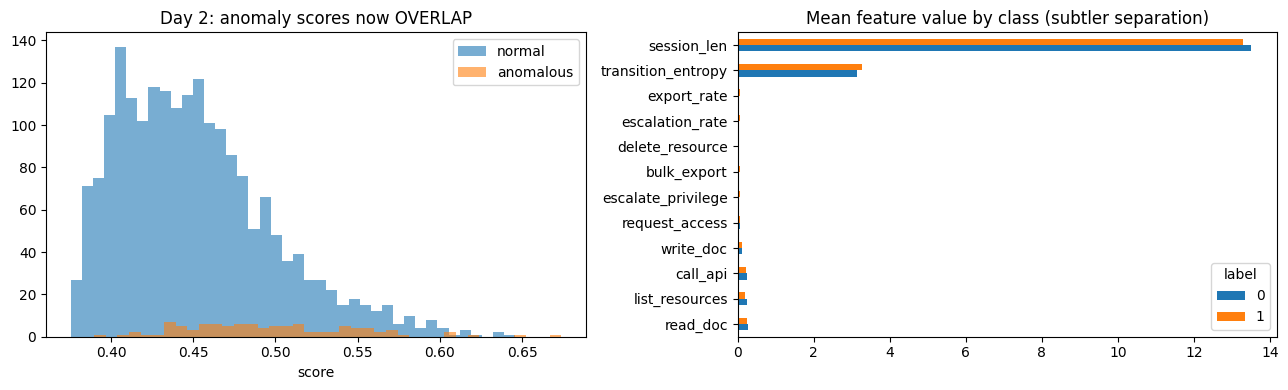

If the two score distributions now overlap a lot, you have built a genuinely hard test.
Day 3 ideas: add an autoencoder and compare; try n-gram transition features;
do proper threshold selection without telling the model the true contamination rate.


In [14]:
# --- Visualize the harder problem: overlap is now the story ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(scores2[labels2==0], bins=40, alpha=0.6, label='normal')
ax[0].hist(scores2[labels2==1], bins=40, alpha=0.6, label='anomalous')
ax[0].set_title('Day 2: anomaly scores now OVERLAP'); ax[0].set_xlabel('score'); ax[0].legend()

means2 = pd.DataFrame(X2, columns=feat_names2).assign(label=labels2).groupby('label').mean().T
means2.plot.barh(ax=ax[1]); ax[1].set_title('Mean feature value by class (subtler separation)')
plt.tight_layout(); plt.show()

print('If the two score distributions now overlap a lot, you have built a genuinely hard test.')
print('Day 3 ideas: add an autoencoder and compare; try n-gram transition features;')
print('do proper threshold selection without telling the model the true contamination rate.')